Loaded 2484 resumes from CSV.
Images will be saved to: /content/resume_images
Generating 10 resume images...
Saved: resume_images/resume_0.png
Saved: resume_images/resume_1.png
Saved: resume_images/resume_2.png
Saved: resume_images/resume_3.png
Saved: resume_images/resume_4.png
Saved: resume_images/resume_5.png
Saved: resume_images/resume_6.png
Saved: resume_images/resume_7.png
Saved: resume_images/resume_8.png
Saved: resume_images/resume_9.png

Generation Complete!


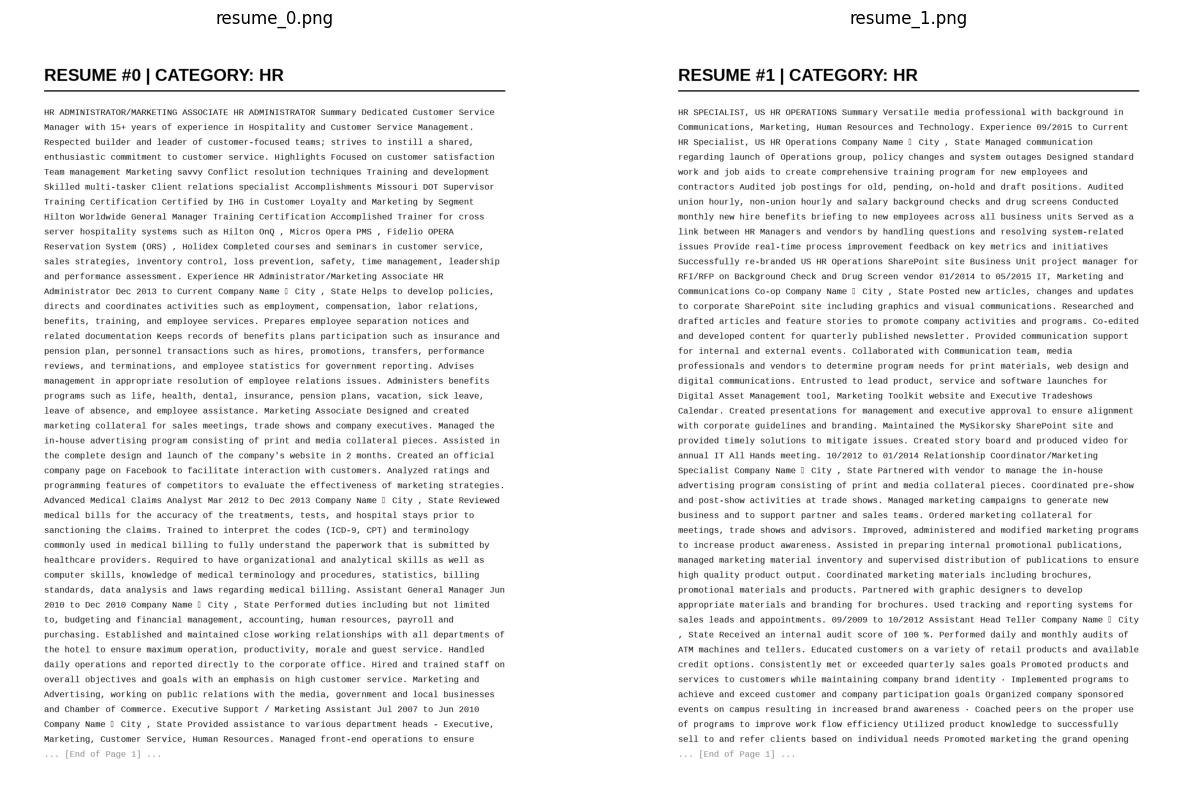

In [4]:
import kagglehub
import pandas as pd
import os
import textwrap
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# --- Step 1: Download and Load Data ---
# (Skipping re-download if path already exists)
try:
    path
except NameError:
    print("Downloading dataset...")
    path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

# Find CSV
csv_file_path = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_file_path = os.path.join(root, file)
            break
    if csv_file_path:
        break

if not csv_file_path:
    raise FileNotFoundError("Could not find any .csv file.")

df = pd.read_csv(csv_file_path)
print(f"Loaded {len(df)} resumes from CSV.")

# --- Step 2: Setup Output Folder ---
output_dir = "resume_images"
os.makedirs(output_dir, exist_ok=True)
print(f"Images will be saved to: {os.path.abspath(output_dir)}")

# --- Step 3: Define Image Generation Function ---
def create_resume_image(text, category, index, output_folder):
    # A4 Dimensions (150 DPI)
    WIDTH, HEIGHT = 1240, 1754
    image = Image.new("RGB", (WIDTH, HEIGHT), "white")
    draw = ImageDraw.Draw(image)

    # Fonts
    try:
        title_font = ImageFont.truetype("LiberationSans-Bold.ttf", 40)
        body_font = ImageFont.truetype("LiberationMono-Regular.ttf", 20)
    except IOError:
        title_font = ImageFont.load_default()
        body_font = ImageFont.load_default()

    # Layout
    MARGIN_X, MARGIN_Y = 80, 80
    current_y = MARGIN_Y

    # 1. Header (Category + ID)
    header = f"RESUME #{index} | CATEGORY: {str(category).upper()}"
    draw.text((MARGIN_X, current_y), header, fill="black", font=title_font)
    current_y += 60
    draw.line((MARGIN_X, current_y, WIDTH - MARGIN_X, current_y), fill="black", width=3)
    current_y += 40

    # 2. Body Text
    clean_text = " ".join(str(text).split()) # Remove messy whitespace
    wrapper = textwrap.TextWrapper(width=90)
    wrapped_text = wrapper.wrap(clean_text)

    for line in wrapped_text:
        draw.text((MARGIN_X, current_y), line, fill="black", font=body_font)
        current_y += 35 # Line height

        # Stop at end of page
        if current_y > HEIGHT - MARGIN_Y:
            draw.text((MARGIN_X, current_y), "... [End of Page 1] ...", fill="gray", font=body_font)
            break

    # Save File
    filename = f"resume_{index}.png"
    filepath = os.path.join(output_folder, filename)
    image.save(filepath)
    return filepath

# --- Step 4: Batch Process (First 10 Rows) ---
NUM_PAGES_TO_GENERATE = 10  # Change this number to generate more

print(f"Generating {NUM_PAGES_TO_GENERATE} resume images...")

generated_files = []

# Iterate through the first N rows
for i, row in df.head(NUM_PAGES_TO_GENERATE).iterrows():
    # Get data safe handling
    text_col = 'Resume_str' if 'Resume_str' in df.columns else 'Resume'
    cat_col = 'Category' if 'Category' in df.columns else 'ID'

    txt = row.get(text_col, "")
    cat = row.get(cat_col, "Unknown")

    # Generate
    file_path = create_resume_image(txt, cat, i, output_dir)
    generated_files.append(file_path)
    print(f"Saved: {file_path}")

print("\nGeneration Complete!")

# --- Step 5: Display a Preview (Top 2) ---
fig, axes = plt.subplots(1, 2, figsize=(15, 10))
for ax, img_path in zip(axes, generated_files[:2]):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(os.path.basename(img_path))
plt.show()